# FINANCIAL DATA ANALYSIS REPORT
## Based on Python for Finance Cookbook (Chapters 1 & 2)

## 0.Introduction
-   This notebook demonstrates financial data processing and analysis:
- Data collection (yfinance)
- Data cleaning
- Feature engineer
- Risk & return metrics
- Visualization
- Portfolio analysis

## 1.Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import pandas_datareader.data as web
import datetime


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Download data (Crypto - BTC)

In [2]:
symbol = "BTC-USD"  # Bitcoin
start_date = "2024-01-01"
end_date = "2026-01-01"

df = yf.download("BTC-USD", interval="1d",
                 start=start_date, end=end_date)

print("Raw Crypto Data (BTC):")
display(df.head())

[*********************100%***********************]  1 of 1 completed

Raw Crypto Data (BTC):


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


-   Các dữ liệu chứng khoán - Bitcoin đã được tải xuống thành công từ 01/01/2025 đến 01/01/2026 đầy đủ.

-   Vì giá trị Crypto như BTC liên tục biến động 24/7 thì khi ta quan sát theo mỗi ngày - daily sẽ mất rất nhiều thông tin quan trọng
-   Do đó ta sử dụng interval argument để chọn tần suất thể hiện , ở đây là 1 giờ 
-   Đây là tiền đề QUAN TRỌNG cho các bước xử lý tiếp theo như là Realized volatility, Intraday trading strategy, Volatility clustering, High-frequency analysis

## 3.DATA CLEANING

In [3]:
#Xóa bỏ các dữ liệu bị thiếu
df["Volume"] = df["Volume"].replace(0, np.nan)
df = df.dropna()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)
    
df = df.dropna()

print("Cleaned Data:")
print(df.info())
display(df.head())

Cleaned Data:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2024-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   731 non-null    float64
 1   High    731 non-null    float64
 2   Low     731 non-null    float64
 3   Open    731 non-null    float64
 4   Volume  731 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.3 KB
None


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347


-   Ở bước này ta sẽ xử lý dữ liệu bị thiếu như có vài row có Volumn = 0 
-   Nguyên nhân không phải do BTC có giao dịch mà do missing data hoặc lỗi từ yfinance
-   Thay vì giữ lại ta nên loại bỏ hẳn thay vì giữ lại sẽ gây khó hiểu cho model và nhiễu biến động

## 4. FEATURE ENGINEERING

## Chuyển đối giá thành lợi nhuận

In [4]:
# Returns
df['Return'] = df['Close'].pct_change() # Tính lợi nhuận đơn giản
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1)) # Tính lợi nhuận logarit

df = df.dropna()

df.head()

Price,Close,High,Low,Open,Volume,Return,Log_Return
Date,,,,,,,
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536,0.017901,0.017743
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118,-0.046928,-0.048065
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210,0.031081,0.030607
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347,-0.000390,-0.000390
2024-01-06,43989.195312,44227.632812,43475.156250,44178.953125,16092503468,-0.003929,-0.003936


### Trước khi chuyển đổi thành lợi nhuận

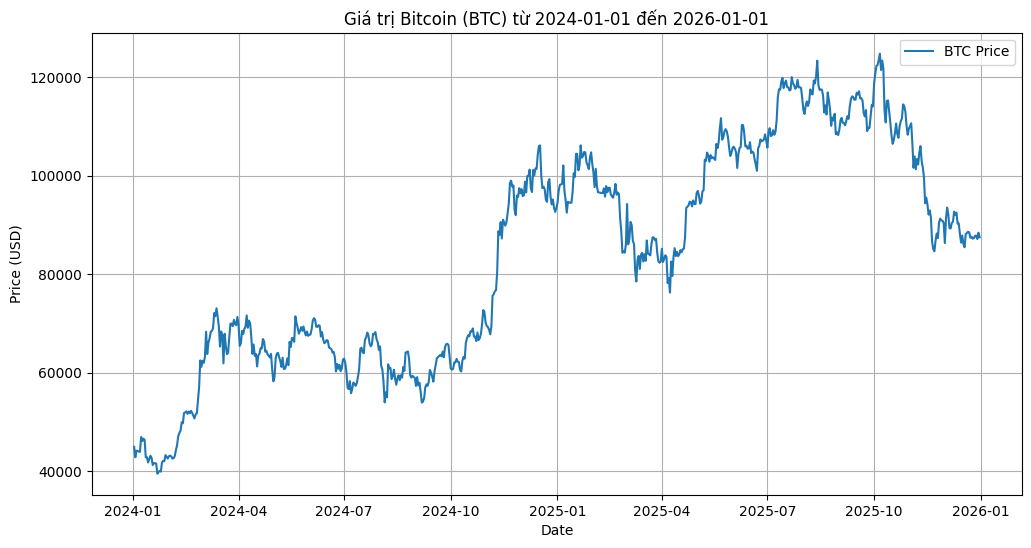

In [26]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='BTC Price')
plt.title('Giá trị Bitcoin (BTC) từ 2024-01-01 đến 2026-01-01')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid()
plt.show()

### Sau khi chuyển đổi thành lợi nhuận

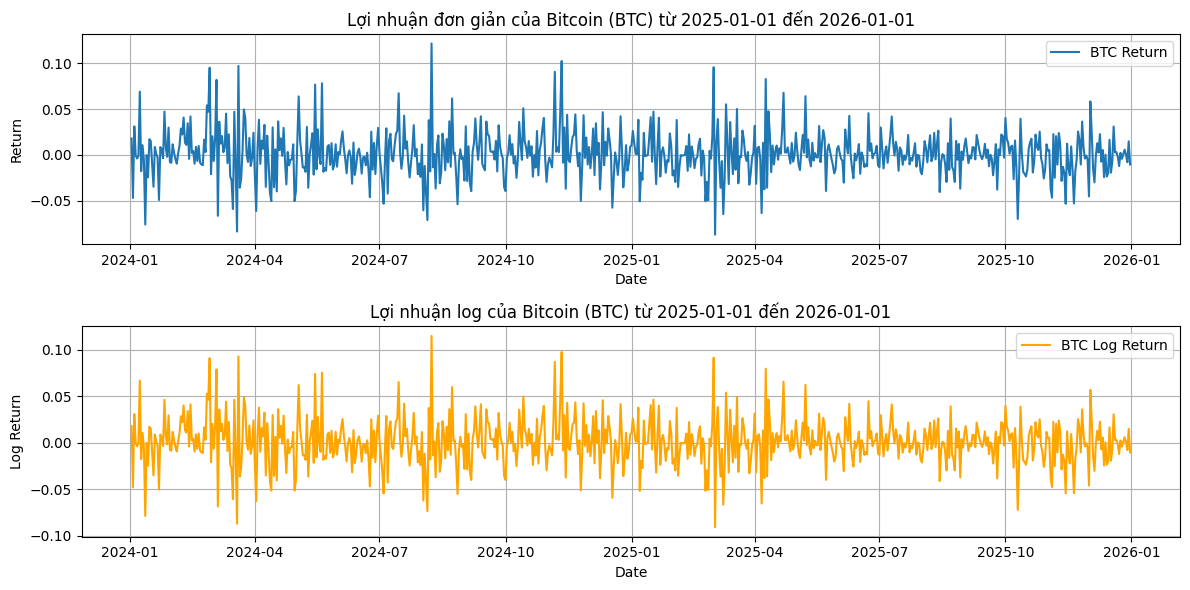

In [27]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Return'], label='BTC Return')
plt.title('Lợi nhuận đơn giản của Bitcoin (BTC) từ 2025-01-01 đến 2026-01-01')  
plt.xlabel('Date')
plt.ylabel('Return')    
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(df.index, df['Log_Return'], label='BTC Log Return', color='orange')
plt.title('Lợi nhuận log của Bitcoin (BTC) từ 2025-01-01 đến 2026-01-01')
plt.xlabel('Date')
plt.ylabel('Log Return')    
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Nhận xét biểu đồ lợi nhuận (Returns, Log Returns)
* Giá trị của 2 loại lợi nhuận không chênh lệch quá nhiều
* Lợi nhuận (Returns) và lợi nhuận log(Log Return) dao động loanh quan giá trị 0
* Xuất hiện giá trị cực trị phản ảnh môi trường có mức độ biến động cao
* Nhìn kĩ vào đầu nằm và cuối năm, ta thấy 2 giai đoạn này có sự biến động liên tục của lợi nhuận còn giữa năm là khoảng thgian khá ổn định

## Điều chỉnh giá theo lạm phát


In [5]:
# Lấy dữ liệu CPI từ FRED
start = datetime.datetime(2023, 12, 1)
end = datetime.datetime(2026, 1, 1)

# CPI Mỹ (All Urban Consumers)
cpi = web.DataReader("CPIAUCSL", "fred", start, end)

cpi.head()

,CPIAUCSL
DATE,
2023-12-01,308.741
2024-01-01,309.698
2024-02-01,310.967
2024-03-01,312.345
2024-04-01,313.023


In [6]:
cpi['Inflation'] = cpi['CPIAUCSL'].pct_change()
cpi = cpi.dropna()

btc = yf.download("BTC-USD", start=start, end=end)
btc.columns = btc.columns.get_level_values(0)

cpi_daily = cpi.resample('D').ffill().bfill()
df = btc.merge(cpi_daily, left_index=True, right_index=True, how='left')

df["Return"] = df['Close'].pct_change()
df["Real_return"] = ((1 + df["Return"]) / (1 + df["Inflation"])) - 1

df = df.dropna()

df.head(5)

C:\Users\MSI VN\AppData\Local\Temp\ipykernel_4468\1529910230.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  cpi['Inflation'] = cpi['CPIAUCSL'].pct_change()
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,CPIAUCSL,Inflation,Return,Real_return
Date,,,,,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443,309.698,0.0031,0.045005,0.041776
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536,309.698,0.0031,0.017901,0.014756
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118,309.698,0.0031,-0.046928,-0.049873
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210,309.698,0.0031,0.031081,0.027894
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347,309.698,0.0031,-0.000390,-0.003479


### So sánh Lợi nhuận đơn giản (Return) và Lợi nhuận sau khi điều chỉnh lạm phát (Real return)

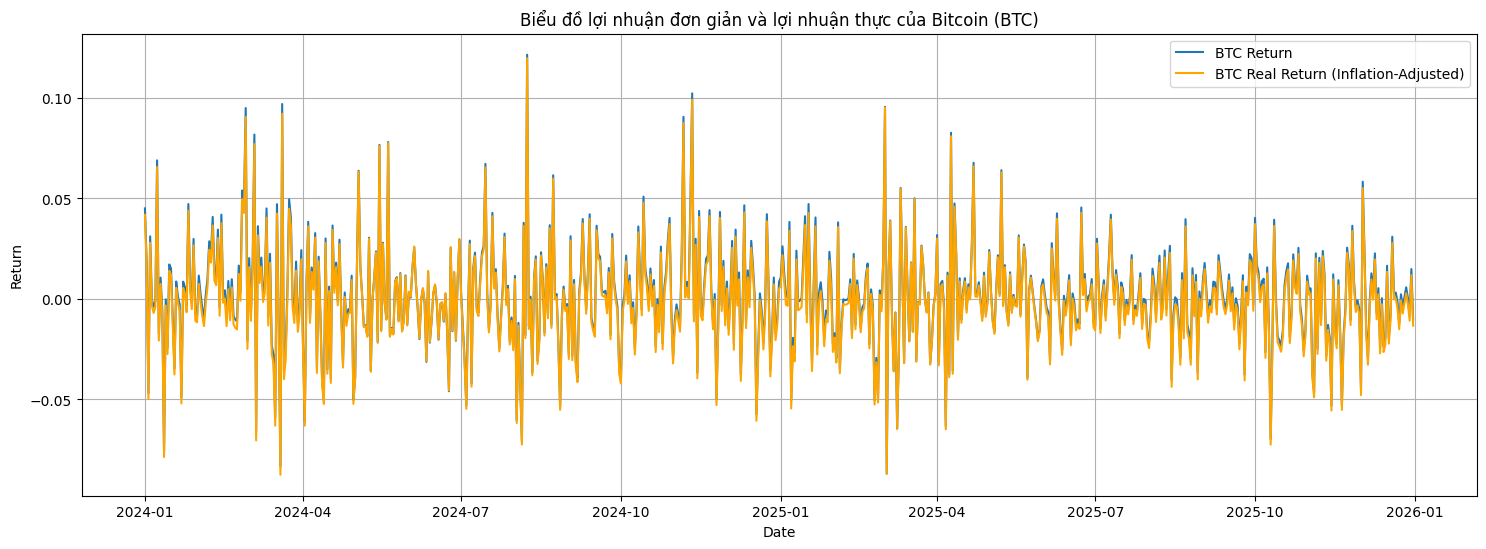

In [31]:
plt.figure(figsize=(18, 6))
plt.plot(df.index, df['Return'], label='BTC Return')
plt.plot(df.index, df['Real_return'], label='BTC Real Return (Inflation-Adjusted)', color='orange')
plt.title('Biểu đồ lợi nhuận đơn giản và lợi nhuận thực của Bitcoin (BTC)')
plt.xlabel('Date')
plt.ylabel('Return')
plt.legend()
plt.grid()
plt.show()

### Nhận xét:
* Biểu đồ cho thấy lợi nhuận đơn giản và lợi nhuận đã được chỉnh sửa có xu hướng biến động gần như tương đồng nhau trong toàn bộ giai đoạn thời gian
* Sự chênh lệch giá trị của 2 loại lợi nhuận chủ yếu do sự lạm phát
* Nhìn chung thì sự điều chỉnh lợi nhuận theo giải pháp không làm thay đổi đáng kể cấu trúc của chuỗi lợi nhuận nhưng vẫn cần thiết để phản ánh giá trị kinh tế trong dài hạn

## Thay đổi tần suất dữ liệu

In [7]:
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

def realized_volatility(x):
    return np.sqrt(np.sum(x**2))
df_rv = (
    df['Log_Return']
    .groupby(pd.Grouper(freq="M"))
    .apply(realized_volatility)
    .to_frame(name='rv')
)
df_rv.rv = df_rv['rv'] * np.sqrt(12)



C:\Users\MSI VN\AppData\Local\Temp\ipykernel_4468\3783269289.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby(pd.Grouper(freq="M"))


In [52]:
df_rv = df['Log_Return'].resample('M').apply(realized_volatility).to_frame(name='rv')

df_rv.rv = df_rv['rv'] * np.sqrt(12)

C:\Users\MSI VN\AppData\Local\Temp\ipykernel_18920\381325944.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_rv = df['Log_Return'].resample('M').apply(realized_volatility).to_frame(name='rv')


In [9]:
df.to_csv("yf_data_processed.csv", index=False)

In [10]:
df.head()

,Close,High,Low,Open,Volume,CPIAUCSL,Inflation,Return,Real_return,Log_Return,rv
Date,,,,,,,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443,309.698,0.0031,0.045005,0.041776,NaN,NaN
2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536,309.698,0.0031,0.017901,0.014756,0.017743,NaN
2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118,309.698,0.0031,-0.046928,-0.049873,-0.048065,NaN
2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210,309.698,0.0031,0.031081,0.027894,0.030607,NaN
2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347,309.698,0.0031,-0.000390,-0.003479,-0.000390,NaN


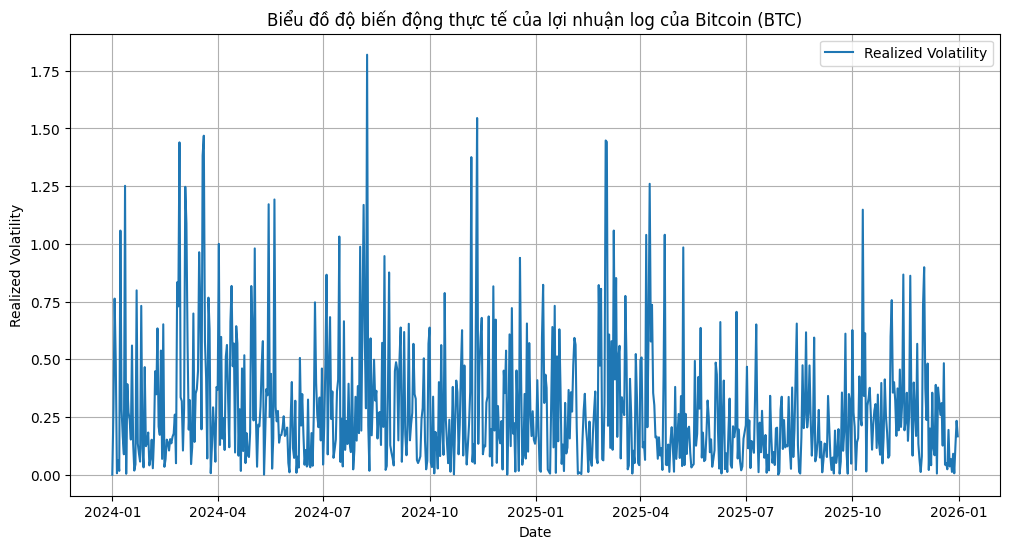

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_rv.index, df_rv['rv'], label='Realized Volatility')
ax.set_title('Biểu đồ độ biến động thực tế của lợi nhuận log của Bitcoin (BTC)')
ax.set_xlabel('Date')
ax.set_ylabel('Realized Volatility')
ax.legend()
ax.grid()
plt.show()

### Nhận xét:
* Biểu đồ cho thấy Realized Volatility của Bitcoin có sự biến động mạnh theo thời gian
* Các đỉnh của volatility thường trùng với các giai đoạn trị trường có các biến động mạnh
* Nhìn chung loại tài sản Bitcoin có độ biến động lớn hơn đáng kể so với các loại tài sản truyền thống

## Các phép điền dữ liệu bị thiếu

### Dữ liệu thiếu

In [12]:
np.random.seed(42)

df_temp = yf.download("BTC-USD", start=start_date, end=end_date, interval="1d", progress=False)
df_temp.columns = df_temp.columns.droplevel(1)

df_temp['Volume_missing'] = df_temp['Volume']

rand_indices = np.random.choice(df_temp.index, 5, replace=False)

df_temp.loc[rand_indices, 'Volume_missing'] = np.nan

df_temp.loc[df_temp.index[0], 'Volume_missing'] = np.nan

df_temp.loc[df_temp['Volume_missing'].isna()]


Price,Close,High,Low,Open,Volume,Volume_missing
Date,,,,,,
2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443,NaN
2024-02-03,42992.250000,43359.941406,42890.808594,43184.964844,11169245236,NaN
2024-10-27,67929.296875,68221.312500,66847.226562,67023.476562,16721307878,NaN
2025-04-01,85169.171875,85487.367188,82429.359375,82551.921875,28175650319,NaN
2025-09-25,109049.289062,113541.085938,108713.398438,113330.164062,75528654284,NaN
2025-12-04,92141.625000,94038.242188,90976.101562,93454.257812,64538402681,NaN


### Điền dữ liệu

In [13]:
df_temp['ffill_volume'] = df_temp['Volume_missing'].fillna(method='ffill') # Điền giá trị bằng phương pháp điền xuôi

df_temp['bfill_volume'] = df_temp['Volume_missing'].fillna(method='bfill') # Điền giá trị bằng phương pháp điền ngược

df_temp['interpolted_volume'] = df_temp['Volume_missing'].interpolate(method="linear") # Điền giá trị bằng phương pháp nội suy tuyến tính

df_temp['Moving_avg_volume'] = df_temp['Volume_missing'].rolling(window=3, min_periods=1).mean() # Điền giá trị bằng phương pháp trung bình động

df_temp.loc[df_temp['Volume_missing'].isna(), ['Volume_missing', 'ffill_volume', 'bfill_volume', 'interpolted_volume', 'Moving_avg_volume']].sort_index()

C:\Users\MSI VN\AppData\Local\Temp\ipykernel_4468\3694245417.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_temp['ffill_volume'] = df_temp['Volume_missing'].fillna(method='ffill') # Điền giá trị bằng phương pháp điền xuôi
C:\Users\MSI VN\AppData\Local\Temp\ipykernel_4468\3694245417.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_temp['bfill_volume'] = df_temp['Volume_missing'].fillna(method='bfill') # Điền giá trị bằng phương pháp điền ngược


Price,Volume_missing,ffill_volume,bfill_volume,interpolted_volume,Moving_avg_volume
Date,,,,,
2024-01-01,NaN,NaN,3.933527e+10,NaN,NaN
2024-02-03,NaN,1.860384e+10,1.480223e+10,1.670303e+10,2.001390e+10
2024-10-27,NaN,1.958810e+10,3.879986e+10,2.919398e+10,3.052904e+10
2025-04-01,NaN,2.900423e+10,4.758440e+10,3.829431e+10,2.188399e+10
2025-09-25,NaN,4.804460e+10,5.773829e+10,5.289144e+10,4.762822e+10
2025-12-04,NaN,7.765020e+10,6.325640e+10,7.045330e+10,7.809850e+10


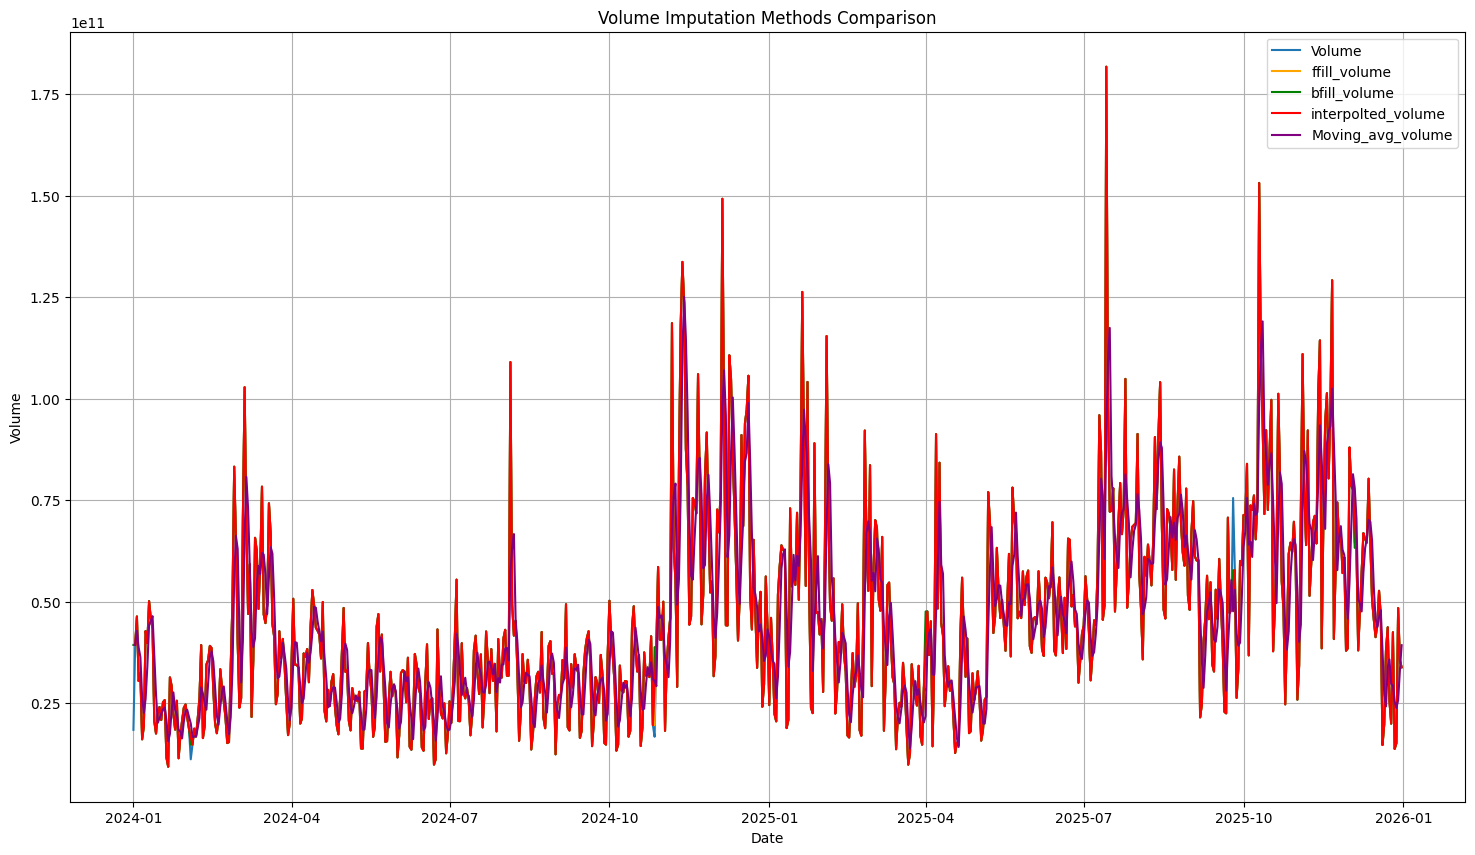

In [45]:
plt.figure(figsize=(18, 10))
plt.plot(df_temp.index, df_temp['Volume'], label='Volume')
plt.plot(df_temp.index, df_temp['ffill_volume'], label='ffill_volume', color='orange')
plt.plot(df_temp.index, df_temp['bfill_volume'], label='bfill_volume', color='green')
plt.plot(df_temp.index, df_temp['interpolted_volume'], label='interpolted_volume', color='red')
plt.plot(df_temp.index, df_temp['Moving_avg_volume'], label='Moving_avg_volume', color='purple')
plt.title('Volume Imputation Methods Comparison')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid()
plt.show()

### Nhận xét:
* Bảng kết quả cho thấy các phương pháp điền dữ liệu thiếu tạo ra giá trị khác nhau đáng kể.
* Phương pháp Forward fill sử dụng giá trị trước đó nên có giá trị thấp hơn so với Backward fill sử dụng giá trị tương lai, cho thấy thị trường đang có xu hướng tăng
* Phương pháp nội suy (interpolation) tạo ra giá trị trung gian hợp lý giữa hai điểm lân cận, phản ánh tốt hơn xu hướng biến động liên tục của dữ liệu. Trong khi đó, trung bình động (moving average) cho kết quả mượt hơn nhưng có thể làm mất đi các biến động ngắn hạn quan trọng.

In [14]:
df_temp.to_csv("imputation_comparison.csv", index=False)